# 02 — Few-Shot Document Classification: 6 Model Comparison
**Group 1 – Invoices | Step 2**

| # | Model | Company | Few-shot strategy |
|---|-------|---------|-------------------|
| 1 | **Qwen2-VL-7B** | Alibaba | 2 images + rich description per class (32 tot) |
| 2 | **Qwen2.5-VL-3B** | Alibaba | 2 images + rich description per class (32 tot) |
| 3 | **CLIP ViT-B/32** | OpenAI | Zero-shot (embedding model) |
| 4 | **SmolVLM-500M** | HuggingFace | 2 images + rich description per class (32 tot) |
| 5 | **PaliGemma2-3B** | Google | Textual few-shot (1 img/class non supportato) |
| 6 | **DiT-large** | Microsoft | Supervised baseline |

**Strategy:** 2 example images + rich textual description per class (32 images total).
The prompt shows: `[img1] [img2] → "These are {class}: {description}"` for every class, then the query.
32 images + CoT-style system prompt → tested on Colab Pro (A100/L4 40GB) without OOM.

> **Improved prompt**: based on Scius-Bertrand et al. (2024) *Zero-Shot Prompting and Few-Shot Fine-Tuning* (arXiv:2412.13859) e su Qwen2.5-VL "plus prompt" strategy (+10% F1 rispetto a prompt base).

> **Checkpoint system**: results are saved after each model run.


## 0 — Environment setup

In [1]:
import os

In [2]:
def _is_kaggle():
    return os.path.exists('/kaggle/working')
def _is_colab():
    try:
        import google.colab
        return not _is_kaggle()
    except ImportError:
        return False
PLATFORM = 'kaggle' if _is_kaggle() else ('colab' if _is_colab() else 'local')
print(PLATFORM)

colab


In [3]:
if PLATFORM == 'colab':
    USE_DRIVE = True
    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')
        OUTPUT_DIR = '/content/drive/MyDrive/NLP_Invoices/outputs'
    else:
        OUTPUT_DIR = '/content/outputs'
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    from huggingface_hub import get_token
    HF_TOKEN = get_token()
    if not HF_TOKEN:
        try:
            from google.colab import userdata
            HF_TOKEN = userdata.get('HF_TOKEN')
        except Exception: pass
    if not HF_TOKEN: raise ValueError('HF_TOKEN not found.')
    from huggingface_hub import login
    login(token=HF_TOKEN)
    print('✅ Colab ready')

Mounted at /content/drive
✅ Colab ready


In [4]:
if PLATFORM == 'kaggle':
    OUTPUT_DIR = '/kaggle/working/outputs'
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    HF_TOKEN = None
    try:
        from kaggle_secrets import UserSecretsClient
        HF_TOKEN = UserSecretsClient().get_secret('HF_TOKEN')
        print('HF_TOKEN loaded from Kaggle Secrets')
    except Exception as _e:
        print(f'Kaggle Secrets not available: {_e}')
    KAGGLE_TOKEN_FILE = '/kaggle/input/MY-HF-TOKEN-DATASET/hf_token.txt'
    if not HF_TOKEN and os.path.isfile(KAGGLE_TOKEN_FILE):
        with open(KAGGLE_TOKEN_FILE) as _f:
            HF_TOKEN = _f.read().strip()
    if not HF_TOKEN: raise ValueError('HF_TOKEN not found.')
    from huggingface_hub import login
    login(token=HF_TOKEN)
    print(f'✅ Kaggle ready. Output → {OUTPUT_DIR}')

In [5]:
if PLATFORM == 'local':
    OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    from huggingface_hub import get_token, login
    HF_TOKEN = get_token() or os.environ.get('HF_TOKEN', '')
    if not HF_TOKEN: raise ValueError('HF_TOKEN not found.')
    login(token=HF_TOKEN)
    print(f'✅ Local ready. Output → {OUTPUT_DIR}')

## 1 — Install dependencies

In [6]:
import sys
!{sys.executable} -m pip install -q einops qwen-vl-utils datasets transformers tqdm
!{sys.executable} -m pip install -q -U 'bitsandbytes>=0.46.1' accelerate
print('✅ Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 47.1 MB/s eta 0:00:00
✅ Dependencies installed


## 1 — Imports & configuration

In [7]:
import random, gc, pickle
from collections import defaultdict
from io import BytesIO

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

N_PER_CLASS   = 100
N_SHOT        = 2     # 2 images per class = 32 images total in context (Colab Pro)
INVOICE_LABEL = 6
RANDOM_SEED   = 42
NUM_WORKERS   = 4
PREFETCH      = 8

os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

try:
    torch.set_num_threads(os.cpu_count())
    torch.set_num_interop_threads(os.cpu_count())
except RuntimeError:
    pass  # already set, ignore

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"CPU cores: {os.cpu_count()}")

LABEL_NAMES = {
    0:"advertisement", 1:"budget", 2:"email", 3:"file folder", 4:"form",
    5:"handwritten", 6:"invoice", 7:"letter", 8:"memo", 9:"news article",
    10:"presentation", 11:"questionnaire", 12:"resume", 13:"scientific publication",
    14:"scientific report", 15:"specification"
}
ALL_LABELS  = list(LABEL_NAMES.keys())
CLASS_NAMES = [LABEL_NAMES[i] for i in ALL_LABELS]

RESULTS = {}
print("Config ready.")

Device: cuda
CPU cores: 48
Config ready.


## 2 — Shared helper functions

In [8]:
def parse_class(text):
    t = text.strip().lower()
    for i, name in enumerate(CLASS_NAMES):
        if t == name: return i
    for i, name in enumerate(CLASS_NAMES):
        if name in t: return i
    for i, name in enumerate(CLASS_NAMES):
        if any(w in t for w in name.split() if len(w) > 3): return i
    return -1


def evaluate(model_name, true_labels, pred_labels, cmap="Blues"):
    unparsed = sum(1 for p in pred_labels if p < 0)
    if unparsed:
        print(f"  ⚠ Unparsed: {unparsed}/{len(pred_labels)} ({100*unparsed/len(pred_labels):.1f}%)")
    # Filter out unparsed predictions (-1) before computing metrics
    valid_mask = [p >= 0 for p in pred_labels]
    tl_v = [t for t, ok in zip(true_labels, valid_mask) if ok]
    pl_v = [p for p, ok in zip(pred_labels, valid_mask) if ok]
    acc      = accuracy_score(tl_v, pl_v) if tl_v else 0.0
    f1_macro = f1_score(tl_v, pl_v, average="macro", zero_division=0) if tl_v else 0.0
    inv_true = [1 if l == INVOICE_LABEL else 0 for l in tl_v]
    inv_pred = [1 if p == INVOICE_LABEL else 0 for p in pl_v]
    inv_f1   = f1_score(inv_true, inv_pred, zero_division=0)
    print(f"\n{'─'*55}\n  {model_name}\n{'─'*55}")
    print(f"  Overall Accuracy : {acc:.3f}")
    print(f"  Macro F1         : {f1_macro:.3f}")
    print(f"  Invoice F1       : {inv_f1:.3f}\n")
    if tl_v:
        print(classification_report(tl_v, pl_v, target_names=CLASS_NAMES,
                                    labels=ALL_LABELS, digits=3, zero_division=0))
    fig, ax = plt.subplots(figsize=(14, 11))
    cm = confusion_matrix(tl_v, pl_v, labels=ALL_LABELS)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap=cmap, xticks_rotation=45)
    ax.set_title(f"{model_name} — Confusion Matrix  (acc={acc:.3f})", fontsize=12, pad=14)
    plt.tight_layout()
    safe = model_name.lower().replace(" ", "_").replace("/", "_")
    path = os.path.join(OUTPUT_DIR, f"cm_{safe}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")
    RESULTS[model_name] = {"preds": pred_labels, "accuracy": acc,
                            "f1_macro": f1_macro, "inv_f1": inv_f1, "unparsed": unparsed}
    return acc, f1_macro, inv_f1


def save_checkpoint():
    path = os.path.join(OUTPUT_DIR, "checkpoint_fewshot.pkl")
    with open(path, "wb") as f:
        pickle.dump({"RESULTS": RESULTS, "true_labels": true_labels}, f)
    print(f"  💾 Checkpoint salvato → {path}  ({list(RESULTS.keys())})")


def load_checkpoint():
    global RESULTS, true_labels
    path = os.path.join(OUTPUT_DIR, "checkpoint_fewshot.pkl")
    if os.path.isfile(path):
        with open(path, "rb") as f:
            ckpt = pickle.load(f)
        RESULTS, true_labels = ckpt["RESULTS"], ckpt["true_labels"]
        print(f"✅ Checkpoint loaded. Already evaluated models: {list(RESULTS.keys())}")
        return True
    return False


def free_memory(*objs):
    # 'del obj' inside the function only drops the local reference;
    # the caller's variables must be deleted separately. We rely on
    # gc.collect() and cuda cache clear to release VRAM after the
    # caller does 'del model' before calling this function.
    gc.collect()
    torch.cuda.empty_cache()
    print("Memory freed.")


def to_pil(image_field):
    if isinstance(image_field, Image.Image):
        return image_field.convert("RGB")
    elif isinstance(image_field, dict):
        return Image.open(BytesIO(image_field["bytes"])).convert("RGB")
    else:
        return Image.fromarray(image_field).convert("RGB")


def resize_img(img, max_size=512):
    w, h = img.size
    if max(w, h) > max_size:
        scale = max_size / max(w, h)
        img = img.resize((int(w*scale), int(h*scale)), Image.LANCZOS)
    return img


class DocDataset(Dataset):
    def __init__(self, examples, max_size=512):
        self.examples = examples
        self.max_size = max_size
    def __len__(self): return len(self.examples)
    def __getitem__(self, i):
        ex  = self.examples[i]
        img = resize_img(to_pil(ex["image"]), self.max_size)
        return img, int(ex["label"])

def pil_collate(batch):
    return [b[0] for b in batch], [b[1] for b in batch]

def make_loader(examples, max_size=512):
    return DataLoader(
        DocDataset(examples, max_size),
        batch_size=1,
        num_workers=NUM_WORKERS,
        prefetch_factor=PREFETCH,
        pin_memory=False,
        collate_fn=pil_collate,
        persistent_workers=True,
    )

print('Helpers ready.')

Helpers ready.


## 2b — Class descriptions (for the text prompt)
Extended visual descriptions for each class, inspired by the RVL-CDIP structure and the *plus prompt* strategy from Scius-Bertrand et al. (2024).
Each class description covers: general visual appearance → layout → key textual elements → discriminative cues.


In [9]:
CLASS_DESCRIPTIONS = {
    "advertisement": (
        "A promotional document designed to sell or market a product, service, or event. "
        "Visually dominant layout with large bold headlines, eye-catching graphics, product photographs "
        "or illustrations, and strong color contrasts. Contains slogans, taglines, pricing information, "
        "discount offers, and calls-to-action ('Call now', 'Buy today'). Company logos and brand names "
        "are prominently displayed. Text is minimal compared to visual elements."
    ),
    "budget": (
        "A financial planning document organized in a strict tabular structure with rows and columns. "
        "Lists budget line items with corresponding monetary amounts, often showing planned vs. actual figures. "
        "Contains fiscal year labels, department names, category headings such as 'Personnel', 'Operating Expenses', "
        "'Revenue', 'Total'. Numbers are right-aligned; grand totals appear at the bottom. "
        "Minimal prose, dominated by numerical data in a spreadsheet-like or ledger format."
    ),
    "email": (
        "A printed electronic mail message. Always begins with structured header fields: 'To:', 'From:', "
        "'Subject:', 'Date:', and sometimes 'Cc:' or 'Bcc:'. "
        "Body is plain prose paragraphs with informal or semi-formal tone. "
        "Ends with a signature block including name, title, phone number, or company. "
        "No decorative borders; monospaced or simple serif font; thread-like reply chains may appear."
    ),
    "file folder": (
        "An image of a physical file folder or its cover/tab. Dominant feature is the folder itself — "
        "a cardboard or manila-colored folder with a protruding tab at the top or side. "
        "The tab may show handwritten or typed labels, reference numbers, dates, or subject codes. "
        "Content is sparse: a title or identifier on the cover, possibly a sticky note or label. "
        "Background is plain; the folder occupies most of the frame."
    ),
    "form": (
        "A structured document with pre-printed fields for data entry. Contains labeled blank lines, "
        "checkboxes, radio buttons, or fillable boxes next to labels like 'Name:', 'Address:', "
        "'Date of Birth:', 'Signature:', 'Department:'. "
        "Layout is rigid and grid-like; fields may be partially or fully filled in by hand or typewriter. "
        "Headers identify the form type (e.g., 'Application Form', 'Request Form'). "
        "Borders and ruled lines define each field."
    ),
    "handwritten": (
        "A page covered primarily or entirely in handwriting — cursive, printed, or a mix. "
        "Lines are irregular; letter spacing is non-uniform. May include corrections, cross-outs, "
        "annotations in margins, or underlined words. Content ranges from personal notes and letters "
        "to lecture notes and calculations. Paper may show ruled lines or be plain. "
        "No printed template structure; the human hand is the dominant visual element."
    ),
    "invoice": (
        "A formal billing document issued by a seller to a buyer. Contains: company letterhead or logo "
        "at top; 'Invoice' or 'Invoice No.' title; billing date and due date; seller and buyer address blocks; "
        "an itemized table listing descriptions of goods or services with quantities, unit prices, and line totals; "
        "subtotal, applicable taxes (VAT/GST), shipping charges, and grand total amount due; "
        "payment terms ('Net 30', 'Due on receipt') and sometimes bank details or PO number. "
        "Structured, professional layout with clear numeric columns."
    ),
    "letter": (
        "A formal or semi-formal written communication. Follows standard letter format: sender's address "
        "and date at top right or left; recipient's name and address below; formal salutation ('Dear Mr./Ms. ...'); "
        "body in full prose paragraphs; formal closing ('Yours sincerely', 'Best regards'); handwritten "
        "or typed signature. May include a subject line ('Re:') and reference number. "
        "Printed on official or personal letterhead. Single-column layout with generous margins."
    ),
    "memo": (
        "An internal business communication, shorter and less formal than a letter. "
        "Begins with the header block: 'MEMORANDUM' or 'MEMO' title, followed by 'TO:', 'FROM:', "
        "'DATE:', 'RE:' or 'SUBJECT:' fields. Body is concise — bullet points, numbered action items, "
        "or short paragraphs. No formal salutation or closing. "
        "Often single-spaced; distributed on plain paper or internal letterhead."
    ),
    "news article": (
        "A newspaper or magazine article with characteristic multi-column layout (2–4 narrow columns). "
        "Large, bold headline at the top spanning one or more columns; byline with author name and date below. "
        "Dense justified body text in small font within narrow columns. "
        "May include embedded photographs with captions, pull-quotes in larger text, or subheadings. "
        "Publication masthead or section label may appear at top. Typical newsprint visual texture."
    ),
    "presentation": (
        "A printed slide or overhead transparency from a presentation deck. "
        "Each page represents one slide: large title text at the top, followed by 3–7 bullet points "
        "in a hierarchical list. Text is sparse and large relative to page size. "
        "May contain diagrams, charts, or simple illustrations. "
        "Slide number or company logo often appear in a corner. Landscape or portrait orientation."
    ),
    "questionnaire": (
        "A survey or assessment instrument with a repeating question-answer structure. "
        "Contains sequentially numbered questions followed by multiple-choice options, Likert scale ratings "
        "(1–5 or Strongly Agree to Strongly Disagree), yes/no checkboxes, or open response lines. "
        "Uniform visual rhythm from top to bottom. May include a title, instructions, and section headers. "
        "Used for research, HR, or customer feedback; visually resembles a standardized test sheet."
    ),
    "resume": (
        "A professional curriculum vitae document. Candidate's full name in large text at the top, "
        "followed by contact information (phone, email, address). "
        "Organized into clearly labeled sections: 'Work Experience', 'Education', 'Skills', "
        "'Certifications', 'Objective'. Each job entry shows company name, job title, and date range "
        "followed by bullet-point responsibilities. Clean, scannable layout with consistent indentation."
    ),
    "scientific publication": (
        "An academic journal article or conference paper. Structured with labeled sections: "
        "Abstract, Introduction, Related Work, Methodology, Results, Discussion, References. "
        "Dense two-column layout is common; text uses formal academic language with in-text citations "
        "(Author, Year) or numbered references [1]. May include equations, theorems, and figure captions. "
        "Author affiliations and journal/conference name appear at the top. Small font, tight line spacing."
    ),
    "scientific report": (
        "A technical or scientific report, often institutional (lab report, field survey, R&D report). "
        "Single-column layout with numbered sections and subsections. Contains data tables, charts, "
        "graphs, experimental results, and technical specifications. "
        "Figures and tables are numbered ('Figure 3', 'Table 2') with descriptive captions below. "
        "Executive summary or abstract at the start; appendices and references at the end. "
        "More visually technical than a scientific publication."
    ),
    "specification": (
        "A technical specification or requirements document with a hierarchical numbered outline "
        "(1. Scope → 1.1 Purpose → 1.1.1 Applicability). "
        "Defines precise requirements, tolerances, standards, and parameters using tables of values. "
        "Contains references to standards bodies (ISO, ANSI, IEEE, MIL-SPEC). "
        "Formal, dry prose with SHALL/MUST language. May include technical drawings, schematics, "
        "or part-number lists. Produced by engineering or standards organizations."
    ),
}
print("Class descriptions pronte.")


Class descriptions pronte.


## 3 — Load datasets
- **Test set** (`test` split): 100 images/class × 16 = 1,600 images total.
- **Few-shot pool** (`train` split): **2/class × 16 = 32 example images** (no leakage with the test set).


In [10]:
true_labels = None
load_checkpoint()

# ── Test set ──────────────────────────────────────────────────────────────
print(f"Loading test set ({N_PER_CLASS}/class...")
test_stream = load_dataset("chainyo/rvl-cdip", split="test", streaming=True
             ).shuffle(seed=RANDOM_SEED, buffer_size=20_000)

test_balanced = defaultdict(list)
test_done = set()
for ex in test_stream:
    label = int(ex["label"])
    if label in test_done: continue
    test_balanced[label].append(ex)
    if len(test_balanced[label]) >= N_PER_CLASS:
        test_done.add(label)
        print(f"  ✓ test/{LABEL_NAMES[label]}")
    if len(test_done) == len(ALL_LABELS): break

all_examples_meta = [ex for exs in test_balanced.values() for ex in exs]
random.seed(RANDOM_SEED)
random.shuffle(all_examples_meta)

if true_labels is None:
    true_labels = [int(ex["label"]) for ex in all_examples_meta]

print(f"\n✅ Test set: {len(all_examples_meta)} examples.")

# ── Few-shot pool: N_SHOT=2 images per class from the train split ──────────
print(f"\nLoading few-shot pool ({N_SHOT}/class from train split)...")
train_stream = load_dataset("chainyo/rvl-cdip", split="train", streaming=True
              ).shuffle(seed=RANDOM_SEED + 1, buffer_size=20_000)

shot_pool = defaultdict(list)   # {label_int: [PIL, PIL, ...]}
shot_done = set()
for ex in train_stream:
    label = int(ex["label"])
    if label in shot_done: continue
    shot_pool[label].append(resize_img(to_pil(ex["image"])))
    if len(shot_pool[label]) >= N_SHOT:
        shot_done.add(label)
        print(f"  ✓ train/{LABEL_NAMES[label]} ({N_SHOT} imgs)")
    if len(shot_done) == len(ALL_LABELS): break

# Lista ordinata: [(img_list, label_int, label_name), ...]
shot_examples = [
    (shot_pool[l], l, LABEL_NAMES[l]) for l in ALL_LABELS
]
print(f"\n✅ Few-shot pool: {N_SHOT * len(ALL_LABELS)} images ({N_SHOT}/class).")
print(f"   Total images in context for inference: {N_SHOT * len(ALL_LABELS)} + 1 query = {N_SHOT * len(ALL_LABELS) + 1}")


Caricamento test set (100/classe)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/119 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

  ✓ test/letter
  ✓ test/specification
  ✓ test/resume
  ✓ test/advertisement
  ✓ test/file folder
  ✓ test/presentation
  ✓ test/questionnaire
  ✓ test/invoice
  ✓ test/memo
  ✓ test/news article
  ✓ test/form
  ✓ test/handwritten
  ✓ test/email
  ✓ test/scientific publication
  ✓ test/budget
  ✓ test/scientific report

✅ Test set: 1600 esempi.

Caricamento few-shot pool (2/classe dal train split)...


Resolving data files:   0%|          | 0/119 [00:00<?, ?it/s]

  ✓ train/file folder (2 imgs)
  ✓ train/resume (2 imgs)
  ✓ train/news article (2 imgs)
  ✓ train/questionnaire (2 imgs)
  ✓ train/advertisement (2 imgs)
  ✓ train/scientific publication (2 imgs)
  ✓ train/presentation (2 imgs)
  ✓ train/form (2 imgs)
  ✓ train/budget (2 imgs)
  ✓ train/email (2 imgs)
  ✓ train/specification (2 imgs)
  ✓ train/memo (2 imgs)
  ✓ train/handwritten (2 imgs)
  ✓ train/scientific report (2 imgs)
  ✓ train/letter (2 imgs)
  ✓ train/invoice (2 imgs)

✅ Few-shot pool: 32 immagini (2/classe).
   Totale immagini nel contesto per inference: 32 + 1 query = 33


---
## Model 1 — Qwen2-VL-7B (Alibaba) — 2-Shot (image + text)
Prompt structured as a multi-turn conversation with an advanced system message:
- **Rich system prompt** with expert persona, internal CoT instructions, and class list
- **16 turns** `user→assistant`: each turn shows **2 example images** + extended description, the assistant conferma
- **Final turn** `user`: query image + structured reasoning instructions → classification

32 images in context → fits on Colab Pro (A100/L4 40GB) with 4-bit quantization.
Inspired by the *plus prompt* strategy from Scius-Bertrand et al. (arXiv:2412.13859): +10% F1 vs. base prompt.


GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM libera: 101.39 GB


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen2-VL-7B loaded.
VRAM dopo caricamento: 5.96 GB


Qwen2-VL-7B 2-shot:   0%|          | 0/1600 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


⚠️  Parse fallito: 9/1600
Done.
  ⚠ Unparsed: 9/1600 (0.6%)

───────────────────────────────────────────────────────
  Qwen2-VL-7B
───────────────────────────────────────────────────────
  Overall Accuracy : 0.389
  Macro F1         : 0.378
  Invoice F1       : 0.612

                        precision    recall  f1-score   support

         advertisement      0.767     0.890     0.824       100
                budget      0.811     0.300     0.438       100
                 email      1.000     0.350     0.519       100
           file folder      0.926     0.253     0.397        99
                  form      0.000     0.000     0.000        96
           handwritten      0.344     0.540     0.420       100
               invoice      0.594     0.630     0.612       100
                letter      0.208     0.707     0.321        99
                  memo      0.164     0.110     0.132       100
          news article      0.803     0.530     0.639       100
          presentation    

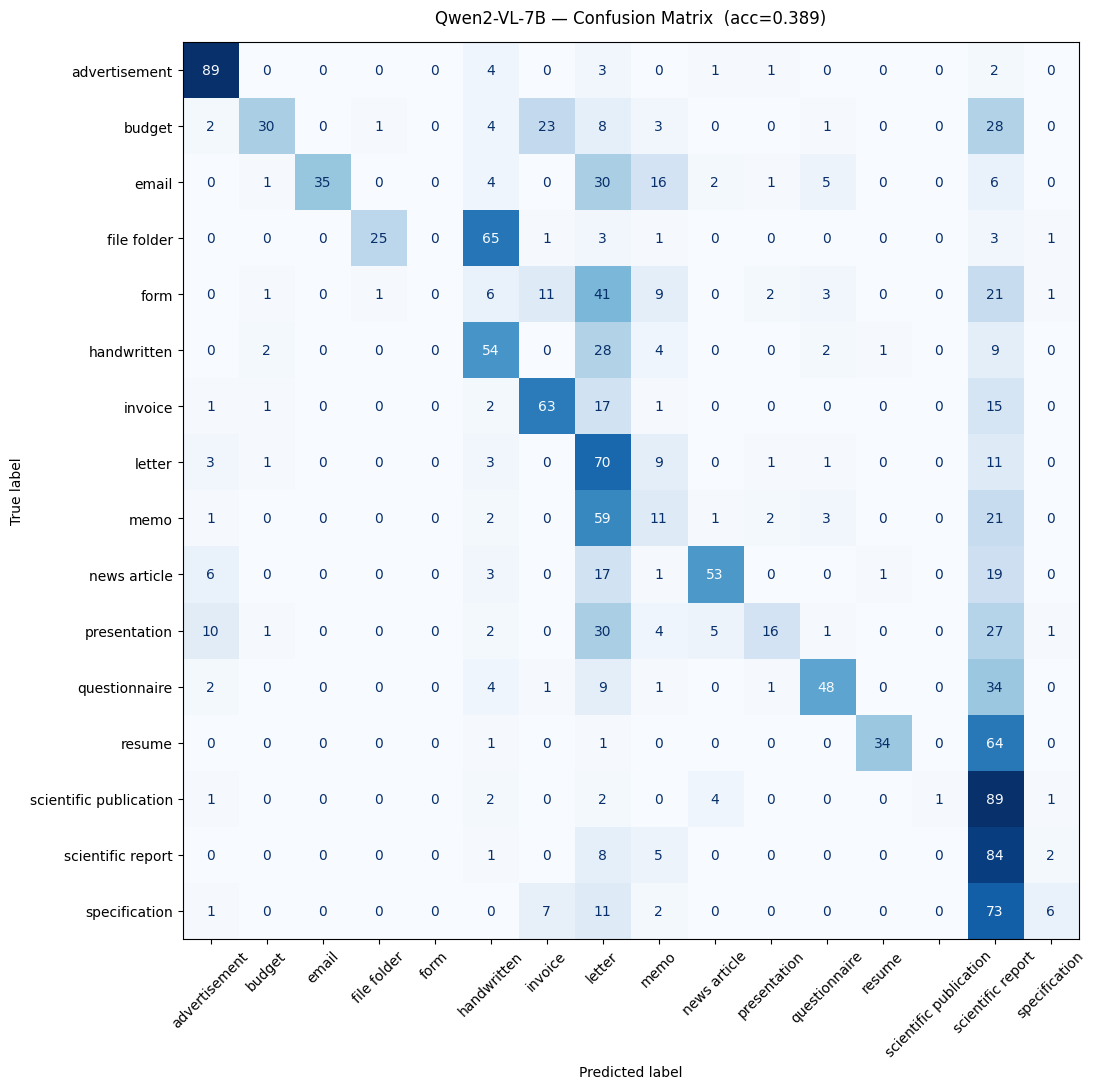

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/cm_qwen2-vl-7b.png
  💾 Checkpoint salvato → /content/drive/MyDrive/NLP_Invoices/outputs/checkpoint_fewshot.pkl  (['Qwen2-VL-7B'])
Memory freed.


In [11]:
if "Qwen2-VL-7B" in RESULTS:
    print("⏭️  Qwen2-VL-7B already evaluated — skipping.")
else:
    import gc, torch
    from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
    from qwen_vl_utils import process_vision_info
    from tqdm.notebook import tqdm

    gc.collect()
    torch.cuda.set_device(0)
    torch.cuda.empty_cache()
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM libera: {torch.cuda.mem_get_info(0)[0]/1e9:.2f} GB")

    bnb4 = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
                               bnb_4bit_use_double_quant=True, bnb_4bit_quant_type="nf4")
    qwen  = Qwen2VLForConditionalGeneration.from_pretrained(
        "Qwen/Qwen2-VL-7B-Instruct", quantization_config=bnb4, device_map={"": 0})
    qproc = AutoProcessor.from_pretrained(
        "Qwen/Qwen2-VL-7B-Instruct", min_pixels=256*28*28, max_pixels=512*28*28)
    qwen.eval()
    print("Qwen2-VL-7B loaded.")
    print(f"VRAM dopo caricamento: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

    # ── System prompt avanzato (plus-prompt strategy) ─────────────────────
    SYSTEM_MSG = (
        "You are an expert document analyst specializing in classifying scanned office documents. "
        "Your task is to identify the document type from a scanned image.\n\n"
        "The 16 possible categories are:\n"
        + "\n".join(f"  {i+1:2d}. {name}" for i, name in enumerate(CLASS_NAMES))
        + "\n\nYou will first see two example images for each category, "
        "along with a detailed visual description. "
        "Study the layout, typography, structural elements, and content patterns carefully. "
        "When classifying a new document, mentally compare its visual features against all 16 categories "
        "and select the single best match.\n"
        "Reply with ONLY the category name — no punctuation, no explanation, no extra words."
    )

    def build_qwen_messages(query_img):
        messages = []
        # First turn: system prompt + first example (2 images)
        first_imgs, _, first_name = shot_examples[0]
        first_desc = CLASS_DESCRIPTIONS[first_name]
        first_content = [
            {"type": "text", "text": SYSTEM_MSG + "\n\nExample documents follow. For each category, two representative images are shown.\n"},
        ]
        for img in first_imgs:
            first_content.append({"type": "image", "image": img})
        first_content.append({"type": "text", "text":
            f"Category: '{first_name}'\nVisual characteristics: {first_desc}"})
        messages.append({"role": "user", "content": first_content})
        messages.append({"role": "assistant", "content":
            f"Understood. I have studied both examples of '{first_name}' and noted its visual characteristics."})

        # Subsequent turns: 2 images per class
        for imgs, _, label_name in shot_examples[1:]:
            desc = CLASS_DESCRIPTIONS[label_name]
            content = []
            for img in imgs:
                content.append({"type": "image", "image": img})
            content.append({"type": "text", "text":
                f"Category: '{label_name}'\nVisual characteristics: {desc}"})
            messages.append({"role": "user", "content": content})
            messages.append({"role": "assistant", "content":
                f"Understood. I have studied both examples of '{label_name}' and noted its visual characteristics."})

        # Final turn: query image with structured reasoning instructions
        messages.append({"role": "user", "content": [
            {"type": "image", "image": query_img},
            {"type": "text", "text": (
                "Classify this document. "
                "Consider its overall layout, presence of tables/columns/fields, "
                "typography style, header structure, and content type. "
                "Choose exactly one category from:\n"
                + ", ".join(CLASS_NAMES)
                + "\nReply with ONLY the category name."
            )},
        ]})
        return messages

    def qwen_classify(query_img):
        messages = build_qwen_messages(query_img)
        text = qproc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = qproc(text=[text], images=image_inputs, videos=video_inputs,
                       padding=True, return_tensors="pt").to("cuda:0")
        with torch.no_grad():
            ids = qwen.generate(**inputs, max_new_tokens=8, do_sample=False)
        return qproc.decode(ids[0][inputs["input_ids"].shape[-1]:],
                            skip_special_tokens=True).strip()

    loader = make_loader(all_examples_meta)
    qwen_preds = []
    failed_indices = []

    for i, (imgs, _) in enumerate(tqdm(loader, desc="Qwen2-VL-7B 2-shot")):
        answer = qwen_classify(imgs[0])
        pred   = parse_class(answer)
        if pred < 0: failed_indices.append(i)
        qwen_preds.append(pred)
        if (i + 1) % 100 == 0:
            gc.collect(); torch.cuda.empty_cache()
            print(f"  VRAM libera: {torch.cuda.mem_get_info(0)[0]/1e9:.2f} GB", end="\r")

    if failed_indices:
        print(f"⚠️  Parse fallito: {len(failed_indices)}/{len(all_examples_meta)}")
    print("Done.")
    evaluate("Qwen2-VL-7B", true_labels, qwen_preds, cmap="Blues")
    save_checkpoint()
    free_memory(qwen, qproc)


---
## Model 2 — Qwen2.5-VL-3B (Alibaba) — 1-Shot (image + text)


VRAM libera: 91.99 GB


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen2.5-VL-3B loaded.


Qwen2.5-VL-3B 2-shot:   0%|          | 0/1600 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


⚠️  Parse fallito: 16/1600
Done.
  ⚠ Unparsed: 16/1600 (1.0%)

───────────────────────────────────────────────────────
  Qwen2.5-VL-3B
───────────────────────────────────────────────────────
  Overall Accuracy : 0.501
  Macro F1         : 0.493
  Invoice F1       : 0.506

                        precision    recall  f1-score   support

         advertisement      0.640     0.970     0.771        99
                budget      0.833     0.202     0.325        99
                 email      0.857     0.480     0.615       100
           file folder      1.000     0.070     0.131       100
                  form      0.372     0.495     0.425        97
           handwritten      0.630     0.800     0.705       100
               invoice      0.618     0.429     0.506        98
                letter      0.741     0.404     0.523        99
                  memo      0.529     0.360     0.429       100
          news article      0.780     0.390     0.520       100
          presentation

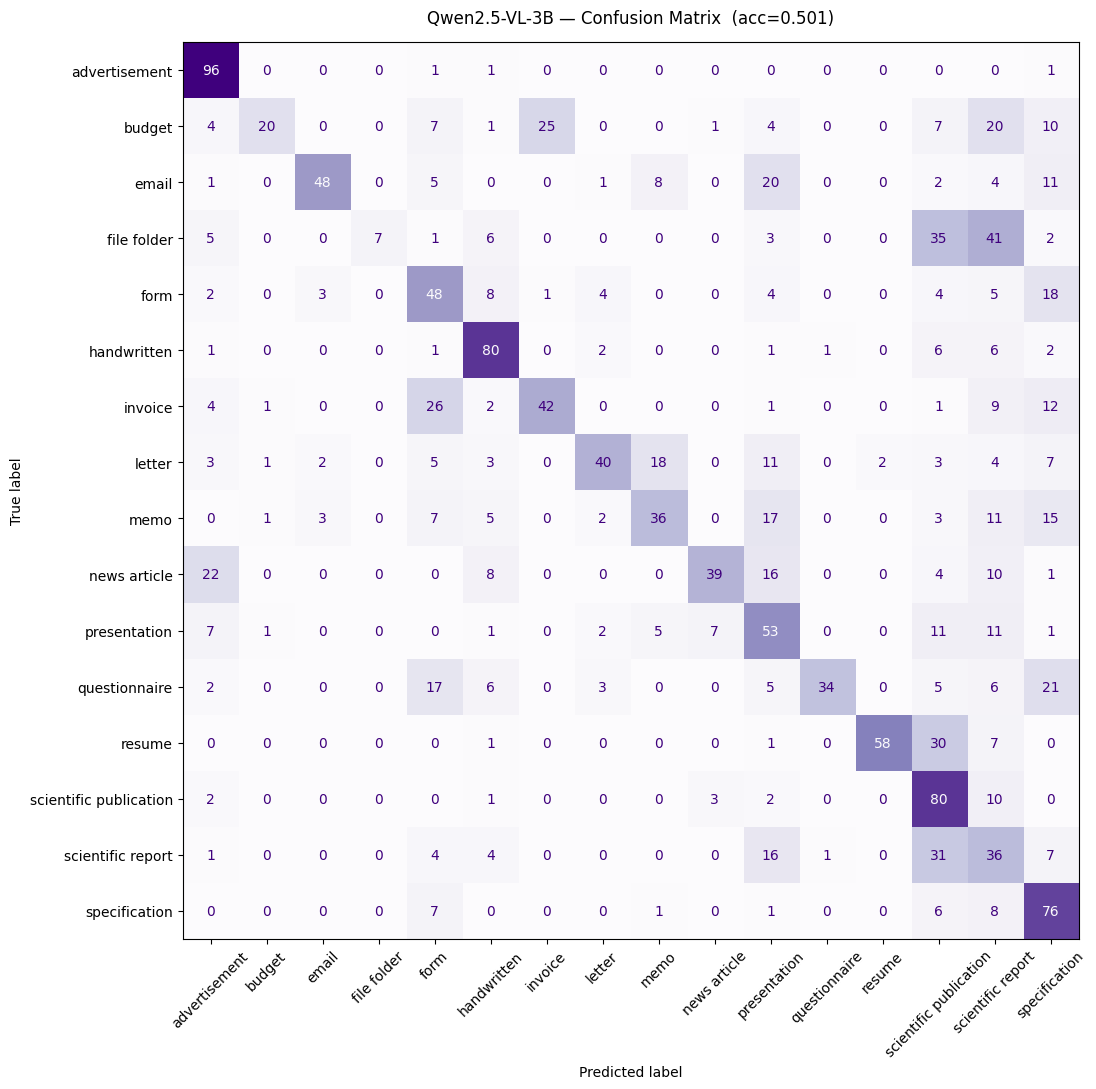

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/cm_qwen2.5-vl-3b.png
  💾 Checkpoint salvato → /content/drive/MyDrive/NLP_Invoices/outputs/checkpoint_fewshot.pkl  (['Qwen2-VL-7B', 'Qwen2.5-VL-3B'])
Memory freed.


In [12]:
if "Qwen2.5-VL-3B" in RESULTS:
    print("⏭️  Qwen2.5-VL-3B already evaluated — skipping.")
else:
    import gc, torch
    from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
    from qwen_vl_utils import process_vision_info
    from tqdm.notebook import tqdm

    gc.collect()
    torch.cuda.set_device(0)
    torch.cuda.empty_cache()
    print(f"VRAM libera: {torch.cuda.mem_get_info(0)[0]/1e9:.2f} GB")

    bnb4 = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
                               bnb_4bit_use_double_quant=True, bnb_4bit_quant_type="nf4")
    qwen25  = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        "Qwen/Qwen2.5-VL-3B-Instruct", quantization_config=bnb4, device_map={"": 0})
    qproc25 = AutoProcessor.from_pretrained(
        "Qwen/Qwen2.5-VL-3B-Instruct", min_pixels=256*28*28, max_pixels=512*28*28)
    qwen25.eval()
    print("Qwen2.5-VL-3B loaded.")

    SYSTEM_MSG_25 = (
        "You are an expert document analyst specializing in classifying scanned office documents. "
        "Your task is to identify the document type from a scanned image.\n\n"
        "The 16 possible categories are:\n"
        + "\n".join(f"  {i+1:2d}. {name}" for i, name in enumerate(CLASS_NAMES))
        + "\n\nYou will first see two example images for each category, "
        "along with a detailed visual description. "
        "Study the layout, typography, structural elements, and content patterns carefully. "
        "When classifying a new document, mentally compare its visual features against all 16 categories "
        "and select the single best match.\n"
        "Reply with ONLY the category name — no punctuation, no explanation, no extra words."
    )

    def build_qwen25_messages(query_img):
        messages = []
        first_imgs, _, first_name = shot_examples[0]
        first_desc = CLASS_DESCRIPTIONS[first_name]
        first_content = [
            {"type": "text", "text": SYSTEM_MSG_25 + "\n\nExample documents follow. For each category, two representative images are shown.\n"},
        ]
        for img in first_imgs:
            first_content.append({"type": "image", "image": img})
        first_content.append({"type": "text", "text":
            f"Category: '{first_name}'\nVisual characteristics: {first_desc}"})
        messages.append({"role": "user", "content": first_content})
        messages.append({"role": "assistant", "content":
            f"Understood. I have studied both examples of '{first_name}' and noted its visual characteristics."})
        for imgs, _, label_name in shot_examples[1:]:
            desc = CLASS_DESCRIPTIONS[label_name]
            content = []
            for img in imgs:
                content.append({"type": "image", "image": img})
            content.append({"type": "text", "text":
                f"Category: '{label_name}'\nVisual characteristics: {desc}"})
            messages.append({"role": "user", "content": content})
            messages.append({"role": "assistant", "content":
                f"Understood. I have studied both examples of '{label_name}' and noted its visual characteristics."})
        messages.append({"role": "user", "content": [
            {"type": "image", "image": query_img},
            {"type": "text", "text": (
                "Classify this document. "
                "Consider its overall layout, presence of tables/columns/fields, "
                "typography style, header structure, and content type. "
                "Choose exactly one category from:\n"
                + ", ".join(CLASS_NAMES)
                + "\nReply with ONLY the category name."
            )},
        ]})
        return messages

    def qwen25_classify(query_img):
        messages = build_qwen25_messages(query_img)
        text = qproc25.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = qproc25(text=[text], images=image_inputs, videos=video_inputs,
                         padding=True, return_tensors="pt").to("cuda:0")
        with torch.no_grad():
            ids = qwen25.generate(**inputs, max_new_tokens=8, do_sample=False)
        return qproc25.decode(ids[0][inputs["input_ids"].shape[-1]:],
                              skip_special_tokens=True).strip()

    loader = make_loader(all_examples_meta)
    qwen25_preds = []
    failed_indices = []

    for i, (imgs, _) in enumerate(tqdm(loader, desc="Qwen2.5-VL-3B 2-shot")):
        answer = qwen25_classify(imgs[0])
        pred   = parse_class(answer)
        if pred < 0: failed_indices.append(i)
        qwen25_preds.append(pred)
        if (i + 1) % 100 == 0:
            gc.collect(); torch.cuda.empty_cache()

    if failed_indices:
        print(f"⚠️  Parse fallito: {len(failed_indices)}/{len(all_examples_meta)}")
    print("Done.")
    evaluate("Qwen2.5-VL-3B", true_labels, qwen25_preds, cmap="Purples")
    save_checkpoint()
    free_memory(qwen25, qproc25)


---
## Model 3 — CLIP ViT-B/32 (OpenAI) — Zero-Shot
Embedding model: uses class descriptions as text prompts for cosine similarity matching.

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded.


CLIP ViT-B/32:   0%|          | 0/1600 [00:00<?, ?it/s]

Done.

───────────────────────────────────────────────────────
  CLIP ViT-B/32
───────────────────────────────────────────────────────
  Overall Accuracy : 0.354
  Macro F1         : 0.313
  Invoice F1       : 0.365

                        precision    recall  f1-score   support

         advertisement      0.943     0.330     0.489       100
                budget      0.487     0.190     0.273       100
                 email      0.833     0.050     0.094       100
           file folder      0.500     0.160     0.242       100
                  form      0.184     0.450     0.262       100
           handwritten      0.938     0.610     0.739       100
               invoice      0.232     0.850     0.365       100
                letter      0.000     0.000     0.000       100
                  memo      0.244     0.400     0.303       100
          news article      0.409     0.830     0.548       100
          presentation      0.264     0.140     0.183       100
         quest

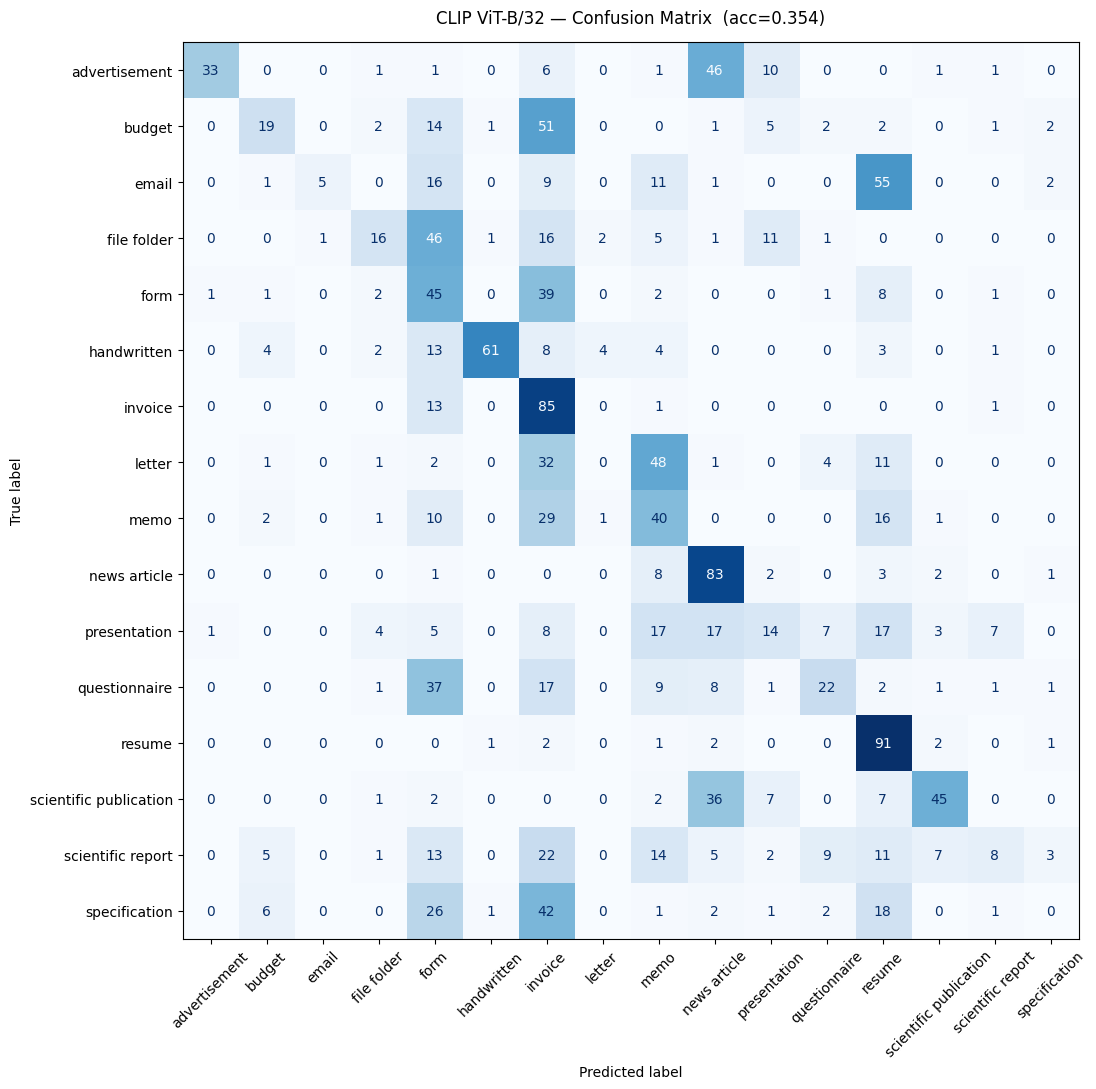

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/cm_clip_vit-b_32.png
  💾 Checkpoint salvato → /content/drive/MyDrive/NLP_Invoices/outputs/checkpoint_fewshot.pkl  (['Qwen2-VL-7B', 'Qwen2.5-VL-3B', 'CLIP ViT-B/32'])
Memory freed.


In [13]:
if "CLIP ViT-B/32" in RESULTS:
    print("⏭️  CLIP ViT-B/32 already evaluated — skipping.")
else:
    import gc, torch
    from transformers import CLIPProcessor, CLIPModel
    from tqdm.notebook import tqdm

    gc.collect(); torch.cuda.empty_cache()

    clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
    proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    clip.eval()
    print("CLIP loaded.")

    CLIP_TEXTS = [
        f"a scanned {name} document: {CLASS_DESCRIPTIONS[name][:100]}"
        for name in CLASS_NAMES
    ]

    loader = make_loader(all_examples_meta)
    clip_preds = []

    for i, (imgs, _) in enumerate(tqdm(loader, desc="CLIP ViT-B/32")):
        inputs = proc(text=CLIP_TEXTS, images=imgs, return_tensors="pt",
                      padding=True, truncation=True, max_length=77).to(DEVICE)
        with torch.no_grad():
            probs = clip(**inputs).logits_per_image.softmax(dim=-1)
        clip_preds.extend(probs.argmax(dim=-1).cpu().tolist())

    print("Done.")
    evaluate("CLIP ViT-B/32", true_labels, clip_preds, cmap="Blues")
    save_checkpoint()
    free_memory(clip, proc)

---
## Model 4 — SmolVLM-500M (HuggingFace) — 2-Shot (image + text)
SmolVLM supports multi-image: all 32 examples + query are passed in a single user turn.


In [14]:
if "SmolVLM-500M" in RESULTS:
    print("⏭️  SmolVLM-500M already evaluated — skipping.")
else:
    import gc, torch
    from transformers import AutoProcessor, Idefics3ForConditionalGeneration

    gc.collect(); torch.cuda.empty_cache()

    smol  = Idefics3ForConditionalGeneration.from_pretrained(
        "HuggingFaceTB/SmolVLM-500M-Instruct",
        torch_dtype=torch.float16, trust_remote_code=True, device_map='auto')
    sproc = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct")
    smol.eval()
    print("SmolVLM-500M loaded.")

    def smol_classify(query_img):
        content = [{"type": "text", "text":
            "You are an expert document analyst. "
            "Below you will see two example images for each of the 16 document categories, "
            "with a detailed visual description. "
            "Study the layout, structure, typography, and content patterns of each category.\n\n"}]
        for imgs, _, label_name in shot_examples:
            desc = CLASS_DESCRIPTIONS[label_name]
            for img in imgs:
                content.append({"type": "image"})
            content.append({"type": "text", "text":
                f"Category: '{label_name}'\nVisual characteristics: {desc}\n"})
        content.append({"type": "text", "text": (
            "\nNow classify the following document image. "
            "Consider its overall layout, presence of tables/columns/fields, "
            "typography style, header structure, and content type. "
            "Choose exactly one from: " + ", ".join(CLASS_NAMES) + ".\n"
            "Reply with ONLY the category name.\nCategory:"
        )})
        content.append({"type": "image"})

        messages = [{"role": "user", "content": content}]
        prompt   = sproc.apply_chat_template(messages, add_generation_prompt=True)
        all_imgs = [img for imgs, _, _ in shot_examples for img in imgs] + [query_img]
        inputs   = sproc(text=prompt, images=all_imgs, return_tensors="pt").to(next(smol.parameters()).device)
        with torch.no_grad():
            ids = smol.generate(**inputs, max_new_tokens=15, do_sample=False)
        input_len = inputs["input_ids"].shape[-1]
        return sproc.decode(ids[0][input_len:], skip_special_tokens=True).strip()

    loader = make_loader(all_examples_meta)
    smol_preds = []
    failed_indices = []

    for i, (imgs, _) in enumerate(tqdm(loader, desc="SmolVLM-500M 2-shot")):
        answer = smol_classify(imgs[0])
        pred   = parse_class(answer)
        if pred < 0: failed_indices.append(i)
        smol_preds.append(pred)
        if (i + 1) % 100 == 0:
            gc.collect(); torch.cuda.empty_cache()

    if failed_indices:
        print(f"⚠️  Parse fallito: {len(failed_indices)}/{len(all_examples_meta)}")
    print("Done.")
    evaluate("SmolVLM-500M", true_labels, smol_preds, cmap="Purples")
    save_checkpoint()
    free_memory(smol, sproc)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

SmolVLM-500M loaded.


SmolVLM-500M 2-shot:   0%|          | 0/1600 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (38946 > 8192). Running this sequence through the model will result in indexing errors


KeyboardInterrupt: 

---
## Model 5 — PaliGemma2-3B (Google) — Textual Few-Shot
PaliGemma accepts a single image per forward pass → textual few-shot using extended class descriptions.
The prompt uses the same rich structure as the other models, but without example images.


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

PaliGemma2-3B loaded.


PaliGemma2-3B:   0%|          | 0/1600 [00:00<?, ?it/s]

⚠️  Parse fallito: 15/1600
Done.
  ⚠ Unparsed: 15/1600 (0.9%)

───────────────────────────────────────────────────────
  PaliGemma2-3B
───────────────────────────────────────────────────────
  Overall Accuracy : 0.063
  Macro F1         : 0.007
  Invoice F1       : 0.000

                        precision    recall  f1-score   support

         advertisement      0.000     0.000     0.000        95
                budget      0.000     0.000     0.000       100
                 email      0.000     0.000     0.000       100
           file folder      0.000     0.000     0.000       100
                  form      0.000     0.000     0.000       100
           handwritten      0.000     0.000     0.000       100
               invoice      0.000     0.000     0.000       100
                letter      0.000     0.000     0.000       100
                  memo      0.000     0.000     0.000       100
          news article      0.000     0.000     0.000        97
          presentation

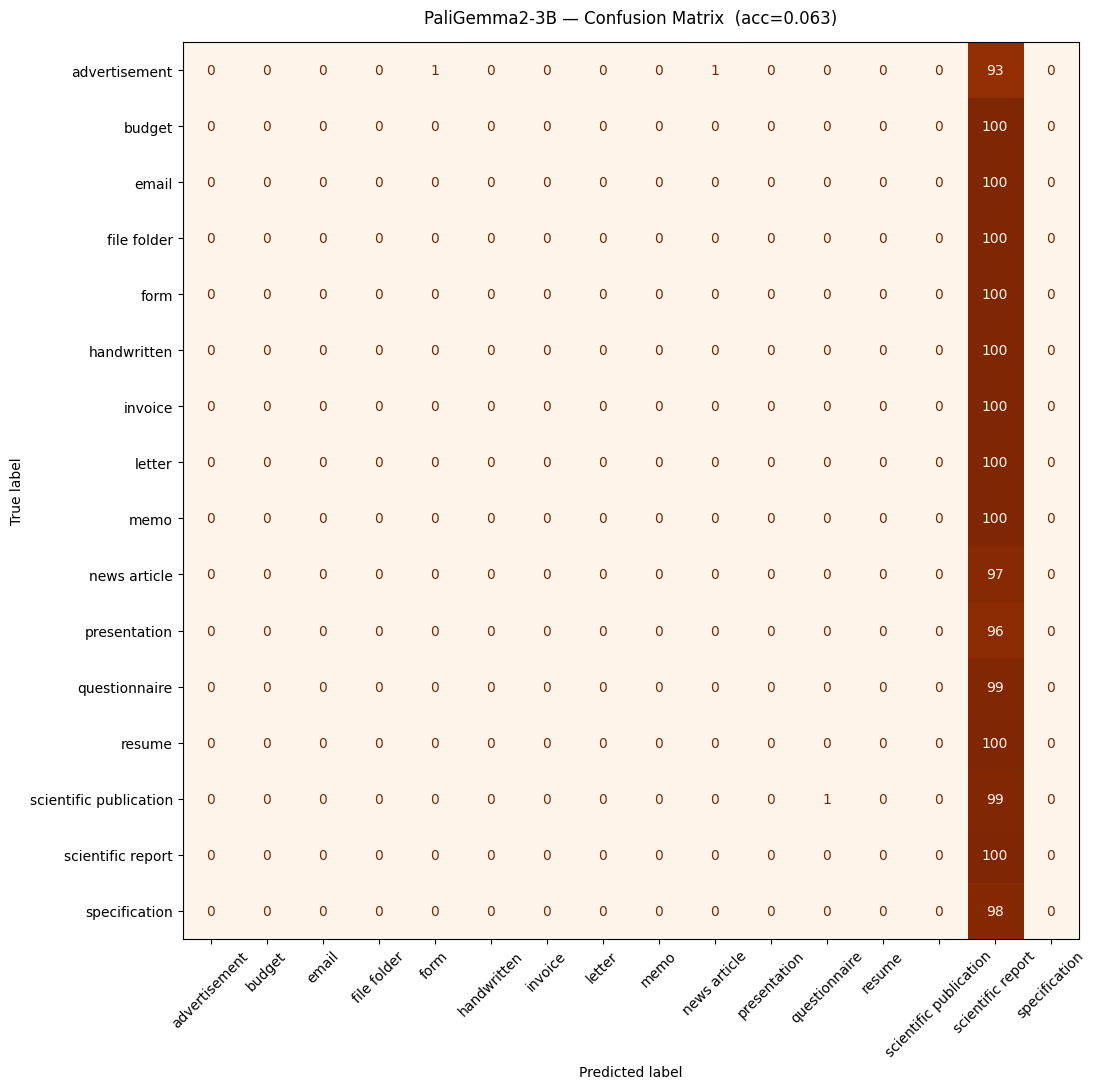

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/cm_paligemma2-3b.png
  💾 Checkpoint salvato → /content/drive/MyDrive/NLP_Invoices/outputs/checkpoint_fewshot.pkl  (['Qwen2-VL-7B', 'Qwen2.5-VL-3B', 'CLIP ViT-B/32', 'PaliGemma2-3B'])
Memory freed.


In [15]:
if "PaliGemma2-3B" in RESULTS:
    print("⏭️  PaliGemma2-3B already evaluated — skipping.")
else:
    import gc, torch
    from transformers import PaliGemmaForConditionalGeneration, AutoProcessor

    gc.collect(); torch.cuda.empty_cache()

    pali  = PaliGemmaForConditionalGeneration.from_pretrained(
        "google/paligemma2-3b-mix-448", torch_dtype=torch.bfloat16,
        token=HF_TOKEN, device_map='auto')
    pproc = AutoProcessor.from_pretrained("google/paligemma2-3b-mix-448", token=HF_TOKEN)
    pali.eval()
    print("PaliGemma2-3B loaded.")

    # Build the textual context once (extended class descriptions)
    PALI_CONTEXT = "\n".join(
        f"  {i+1:2d}. {name}: {CLASS_DESCRIPTIONS[name]}" for i, name in enumerate(CLASS_NAMES)
    )
    PALI_PROMPT = (
        "<image>You are an expert document analyst specializing in classifying scanned office documents.\n\n"
        "Document categories and their detailed visual characteristics:\n"
        + PALI_CONTEXT
        + "\n\nClassify the document image above. "
        "Consider its overall layout, presence of tables/columns/fields, "
        "typography style, header structure, and content type. "
        "Choose exactly one category from the 16 listed above.\n"
        "Answer with only the category name."
    )

    def pali_classify(query_img):
        inputs = pproc(text=PALI_PROMPT, images=query_img, return_tensors="pt").to(next(pali.parameters()).device)
        input_len = inputs["input_ids"].shape[-1]
        with torch.inference_mode():
            ids    = pali.generate(**inputs, max_new_tokens=15, do_sample=False)
            answer = pproc.decode(ids[0][input_len:], skip_special_tokens=True)
        return answer

    loader = make_loader(all_examples_meta)
    pali_preds = []
    failed_indices = []

    for i, (imgs, _) in enumerate(tqdm(loader, desc="PaliGemma2-3B")):
        answer = pali_classify(imgs[0])
        pred   = parse_class(answer)
        if pred < 0: failed_indices.append(i)
        pali_preds.append(pred)
        if (i + 1) % 100 == 0:
            gc.collect(); torch.cuda.empty_cache()

    if failed_indices:
        print(f"⚠️  Parse fallito: {len(failed_indices)}/{len(all_examples_meta)}")
    print("Done.")
    evaluate("PaliGemma2-3B", true_labels, pali_preds, cmap="Oranges")
    save_checkpoint()
    free_memory(pali, pproc)


---
## Model 6 — DiT-large (Microsoft) ⚠️ Supervised baseline

preprocessor_config.json:   0%|          | 0.00/302 [00:00<?, ?B/s]

The image processor of type `BeitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/416 [00:00<?, ?it/s]

DiT-large loaded. GPU: 17.34 GB


DiT-large:   0%|          | 0/1600 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Done.

───────────────────────────────────────────────────────
  DiT-large
───────────────────────────────────────────────────────
  Overall Accuracy : 0.930
  Macro F1         : 0.930
  Invoice F1       : 0.925

                        precision    recall  f1-score   support

         advertisement      0.931     0.940     0.935       100
                budget      0.895     0.940     0.917       100
                 email      1.000     1.000     1.000       100
           file folder      0.941     0.960     0.950       100
                  form      0.913     0.840     0.875       100
           handwritten      0.951     0.970     0.960       100
               invoice      0.921     0.930     0.925       100
                letter      0.933     0.970     0.951       100
                  memo      0.979     0.950     0.964       100
          news article      0.927     0.890     0.908       100
          presentation      0.817     0.850     0.833       100
         questionn

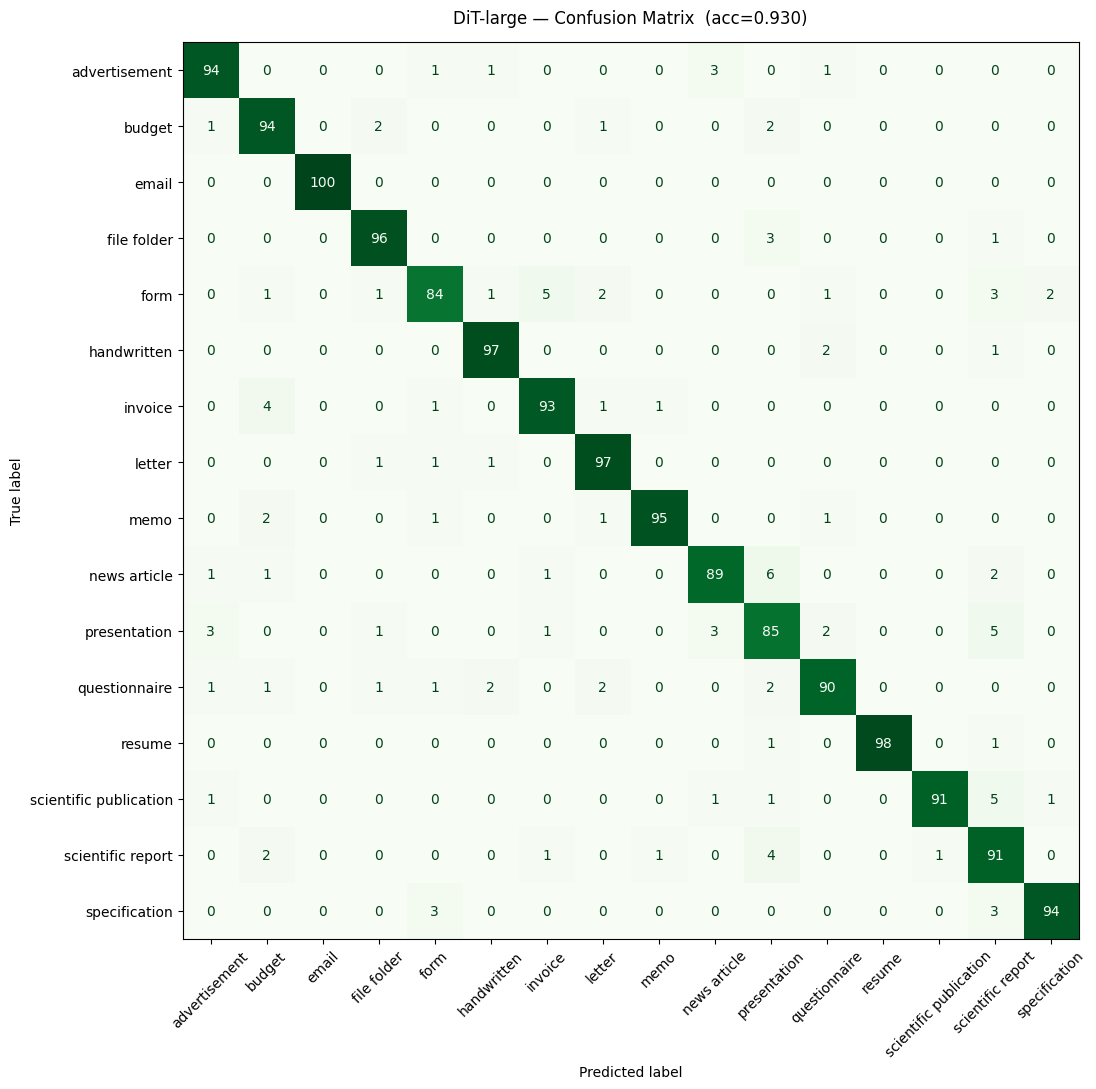

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/cm_dit-large.png
  💾 Checkpoint salvato → /content/drive/MyDrive/NLP_Invoices/outputs/checkpoint_fewshot.pkl  (['Qwen2-VL-7B', 'Qwen2.5-VL-3B', 'CLIP ViT-B/32', 'PaliGemma2-3B', 'DiT-large'])
Memory freed.


In [16]:
if "DiT-large" in RESULTS:
    print("⏭️  DiT-large already evaluated — skipping.")
else:
    import gc, torch
    from transformers import AutoImageProcessor, AutoModelForImageClassification
    from tqdm.notebook import tqdm

    gc.collect(); torch.cuda.empty_cache()

    DIT_ID    = "microsoft/dit-large-finetuned-rvlcdip"
    dit_proc  = AutoImageProcessor.from_pretrained(DIT_ID)
    dit_model = AutoModelForImageClassification.from_pretrained(DIT_ID).to(DEVICE)
    dit_model.eval()
    print(f"DiT-large loaded. GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

    def classify_dit(img):
        inputs = dit_proc(images=img.convert("RGB"), return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            logits = dit_model(**inputs).logits
        return parse_class(dit_model.config.id2label[logits.argmax(-1).item()])

    loader = make_loader(all_examples_meta)
    dit_preds = []

    for i, (imgs, _) in enumerate(tqdm(loader, desc="DiT-large")):
        dit_preds.append(classify_dit(imgs[0]))
        if (i + 1) % 100 == 0: gc.collect()

    print("Done.")
    evaluate("DiT-large", true_labels, dit_preds, cmap="Greens")
    save_checkpoint()
    free_memory(dit_model, dit_proc)

## 4 — Final comparison

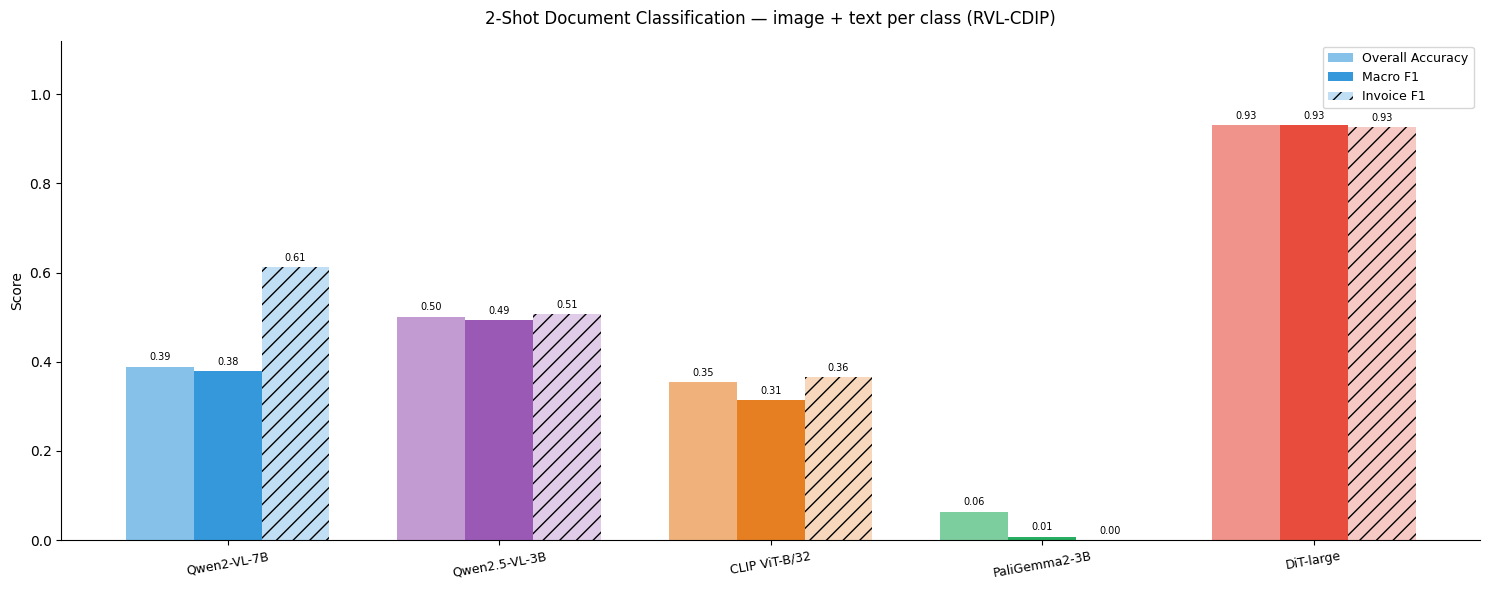

Saved → /content/drive/MyDrive/NLP_Invoices/outputs/02_fewshot_comparison.png

── Summary table ──────────────────────────────────────────
Model                       Accuracy   Macro F1   Invoice F1   Unparsed
──────────────────────────────────────────────────────────────────────
Qwen2-VL-7B                    0.389       0.378       0.612          9
Qwen2.5-VL-3B                  0.501       0.493       0.506         16
CLIP ViT-B/32                  0.354       0.313       0.365          0
PaliGemma2-3B                  0.063       0.007       0.000         15
DiT-large                      0.930★      0.930       0.925★         0
  ★ = best in category


In [17]:
model_names = list(RESULTS.keys())
accs     = [RESULTS[m]["accuracy"]  for m in model_names]
f1_macro = [RESULTS[m]["f1_macro"]  for m in model_names]
inv_f1   = [RESULTS[m]["inv_f1"]    for m in model_names]

colours = ["#3498db", "#9b59b6", "#e67e22", "#27ae60", "#e74c3c", "#1abc9c", "#f39c12"]
x = np.arange(len(model_names))
w = 0.25

fig, ax = plt.subplots(figsize=(15, 6))
b1 = ax.bar(x-w, accs,     w, label="Overall Accuracy", color=[c for c in colours[:len(model_names)]], alpha=0.6)
b2 = ax.bar(x,   f1_macro, w, label="Macro F1",         color=colours[:len(model_names)])
b3 = ax.bar(x+w, inv_f1,   w, label="Invoice F1",       color=colours[:len(model_names)], alpha=0.3, hatch="//")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9, rotation=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.set_title("2-Shot Document Classification — image + text per class (RVL-CDIP)", fontsize=12, pad=12)
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()

path = os.path.join(OUTPUT_DIR, "02_fewshot_comparison.png")
fig.savefig(path, dpi=150)
plt.show()
print(f"Saved → {path}")

print("\n── Summary table ──────────────────────────────────────────")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Invoice F1':>12} {'Unparsed':>10}")
print("─" * 70)
for m in model_names:
    r = RESULTS[m]
    best_acc = "★" if r["accuracy"] == max(accs)   else " "
    best_inv = "★" if r["inv_f1"]   == max(inv_f1) else " "
    print(f"{m:<25} {r['accuracy']:>10.3f}{best_acc} {r['f1_macro']:>10.3f}  {r['inv_f1']:>10.3f}{best_inv} {r['unparsed']:>9}")
print("  ★ = best in category")

## 5 — Save all results

In [18]:
results_path = os.path.join(OUTPUT_DIR, "02_fewshot_results.txt")
with open(results_path, "w") as f:
    f.write("1-Shot Document Classification (image + text) — Results\n")
    f.write("=" * 55 + "\n\n")
    f.write(f"Dataset  : chainyo/rvl-cdip (test split)\n")
    f.write(f"Test set : {N_PER_CLASS}/class × {len(ALL_LABELS)} = {len(all_examples_meta)}\n")
    f.write(f"Few-shot : {N_SHOT} image + description per class (train split)\n")
    f.write(f"Device   : {DEVICE}\n\n")
    f.write(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Invoice F1':>12} {'Unparsed':>10}\n")
    f.write("─" * 70 + "\n")
    for m in model_names:
        r = RESULTS[m]
        f.write(f"{m:<25} {r['accuracy']:>10.3f} {r['f1_macro']:>10.3f}"
                f" {r['inv_f1']:>12.3f} {r['unparsed']:>10}\n")
    f.write("\n")
    for m in model_names:
        f.write(f"\n{'═'*55}\n{m}\n{'═'*55}\n")
        parsed_mask = [p >= 0 for p in RESULTS[m]['preds']]
        tl_p = [t for t, ok in zip(true_labels, parsed_mask) if ok]
        pl_p = [p for p, ok in zip(RESULTS[m]['preds'], parsed_mask) if ok]
        f.write(classification_report(tl_p, pl_p, target_names=CLASS_NAMES,
                                      labels=ALL_LABELS, digits=3, zero_division=0))

print(f"Results saved → {results_path}")
print("\n✅ Step 2 (1-shot image+text) complete.")

Results saved → /content/drive/MyDrive/NLP_Invoices/outputs/02_fewshot_results.txt

✅ Step 2 (1-shot image+text) complete.
